# This notebook includes experimentaion and implementation of power transformers like:
<li> box cox transformer
<li> yeo johnson transformer

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer,OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
import scipy.stats as stats

In [116]:
df = pd.read_csv("insurance.csv")
df['region'].value_counts()
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [117]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [118]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [119]:
X = df.drop(columns=['charges'])
y = df['charges']

In [120]:
X

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest
1334,18,female,31.920,0,no,northeast
1335,18,female,36.850,0,no,southeast
1336,21,female,25.800,0,no,southwest


In [121]:
from sklearn.model_selection import train_test_split


X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [151]:
plot_df = X_train[['age','bmi']]

# Plotting the distplot and QQ plots of predictors with out transformation.

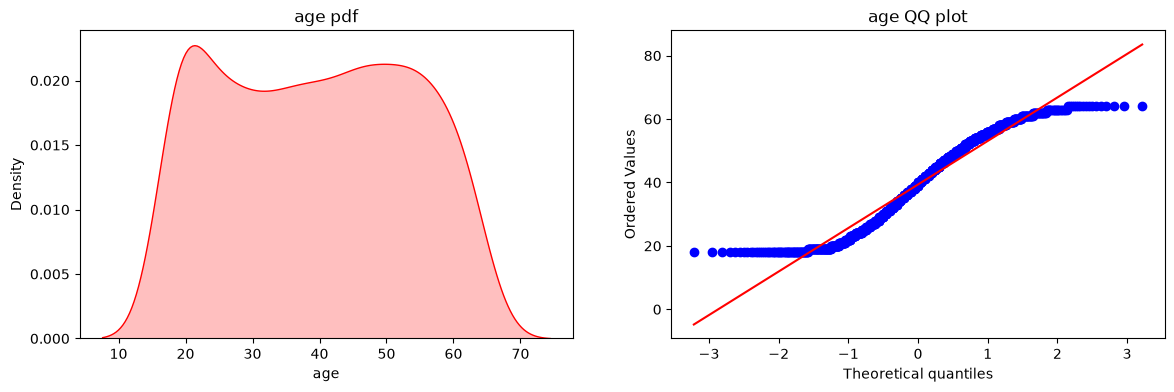

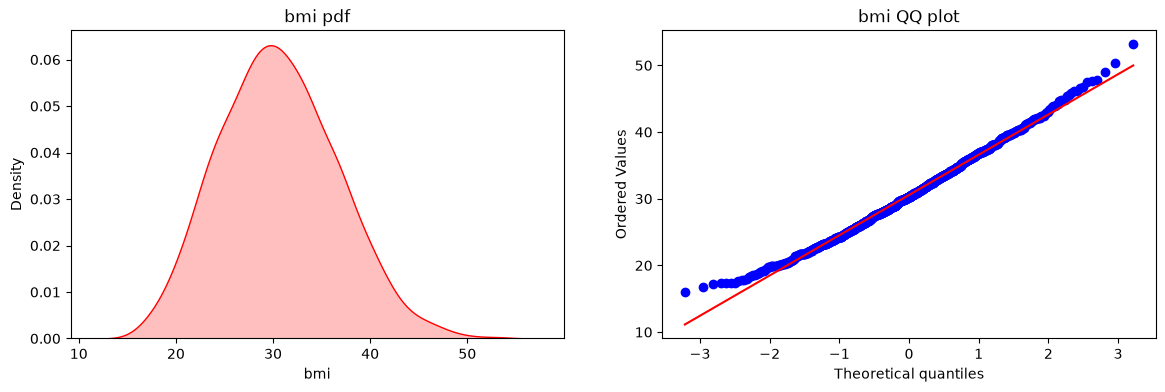

In [ ]:
from matplotlib.pyplot import plot


for cols in X_train.columns: # note: we dont apply transformations to one hot endcoded columns and thus dont require to plot distribution/QQ plots and analyze or check 
                             # ohe columns for normality, as they contain only 0's and 1's . the assumption of normality in linear models applies striclty to continous variables.
    if ( cols in plot_df.columns):  
        fig,(ax1,ax2) = plt.subplots(1,2,figsize=(14,4))
        sns.kdeplot(plot_df[cols],fill=True,color='red',ax=ax1)
        ax1.set_title(f"{cols} pdf")
        stats.probplot(plot_df[cols],dist='norm',plot = ax2)
        ax2.set_title(f"{cols} QQ plot")


# Plotting distplot and QQ plot of target variable with out transformation

skewness of target variable 1.515


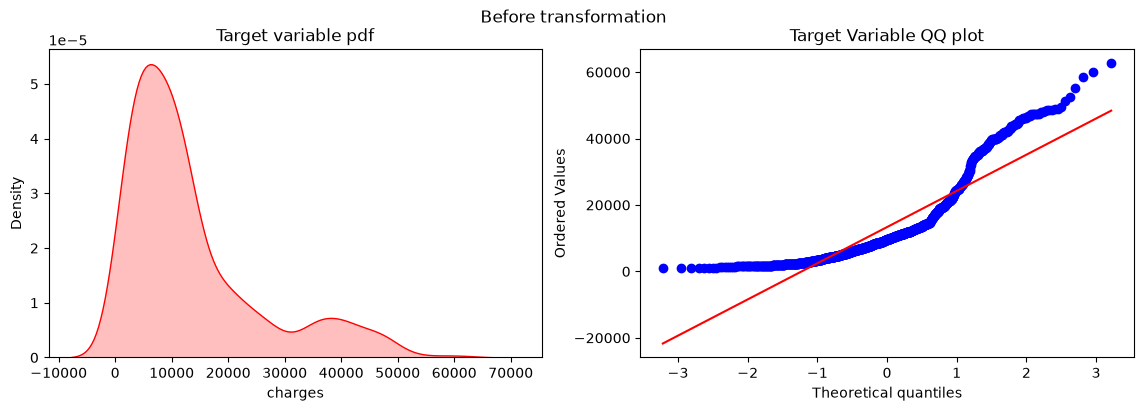

In [153]:
# we are also checking if our target variable is highly skewed and is non-normally distributed.
print("skewness of target variable",np.round(y_train.skew(),3)) # it is highly right skewed , so we need to transform(normalize) it too

# plotting the distribution plot and QQ plot of target variable.

fig,(ax1,ax2) = plt.subplots(1,2,figsize=(14,4))
fig.suptitle("Before transformation")
sns.kdeplot(y_train,fill=True,color='red',ax=ax1)
ax1.set_title(f"Target variable pdf")
stats.probplot(y_train,dist='norm',plot = ax2)
ax2.set_title(f"Target Variable QQ plot")
plt.show()


# Encoding the categorical features 


In [ ]:
tfr = ColumnTransformer([
    ('encoder',OneHotEncoder(drop='first',sparse_output=False,dtype=int),['sex','smoker','region']),
], remainder='passthrough',verbose_feature_names_out=False)
tfr.set_output(transform='pandas')
X_train_encoded = tfr.fit_transform(X_train)
X_test_encoded = tfr.transform(X_test)
X_train_encoded 

,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,age,bmi,children
560,0,0,1,0,0,46,19.950,2
1285,0,0,0,0,0,47,24.320,0
1142,0,0,0,1,0,52,24.860,0
969,0,0,0,1,0,39,34.320,5
486,0,0,1,0,0,54,21.470,3
...,...,...,...,...,...,...,...,...
1095,0,0,0,0,0,18,31.350,4
1130,0,0,0,1,0,39,23.870,5
1294,1,0,0,0,0,58,25.175,0
860,0,1,0,0,1,37,47.600,2


# LR model with out transformation.


In [146]:
from sklearn.linear_model import LinearRegression


lr = LinearRegression()
lr.fit(X_train_encoded,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ -18.59,23651.13, -370.68,..., 256.98, 337.09, 425.28]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['sex_male','smoker_yes','region_northwest',...,'age','bmi','children']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.193e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [154]:
from sklearn.metrics import r2_score

y_pred = lr.predict(X_test_encoded)
r2_score(y_test,y_pred)

0.7835929767120724

In [155]:
# cross checking with cross val score
from sklearn.model_selection import cross_val_score
print("R2 score = ",np.mean(cross_val_score(lr,X_train_encoded,y_train,cv=10,scoring='r2')))

R2 score =  0.7297411102077802


In [156]:
X_train

,age,sex,bmi,children,smoker,region
560,46,female,19.950,2,no,northwest
1285,47,female,24.320,0,no,northeast
1142,52,female,24.860,0,no,southeast
969,39,female,34.320,5,no,southeast
486,54,female,21.470,3,no,northwest
...,...,...,...,...,...,...
1095,18,female,31.350,4,no,northeast
1130,39,female,23.870,5,no,southeast
1294,58,male,25.175,0,no,northeast
860,37,female,47.600,2,yes,southwest


# LR model with transformation(box cox) (MANUAL WAY)

In [247]:
# from kde plot and QQ plot, observation tells bmi is already normally distributed, so it doesnt need to be transformed.
# age and charges(target variable are skewed(has certain skewness). also they have no null values or (negative or 0 ) values,thus we can safely apply box cox with out any modification.

# here i am trying to apply encoding and transformation as pipleine, so X_train and y_train is fitted here again.

ct = ColumnTransformer([
    ('transform',PowerTransformer(method='box-cox'),['age']),
    ('encode',OneHotEncoder(drop='first',sparse_output=False,dtype=int),['sex','smoker','region'])
],remainder= 'passthrough',verbose_feature_names_out=False)

In [248]:
X_train_transformed = ct.fit_transform(X_train)
X_test_transformed =  ct.transform(X_test)

In [249]:
tfr = PowerTransformer(method='box-cox')

In [250]:
y_train_transformed = tfr.fit_transform(y_train.values.reshape(-1,1))
y_train_transformed

array([[-0.01277119],
       [-0.09443974],
       [ 1.21625813],
       ...,
       [ 0.27618   ],
       [ 1.84897385],
       [ 0.10342611]], shape=(1070, 1))

In [251]:
y_test_transformed = tfr.transform(y_test.values.reshape(-1,1))

In [252]:
lr.fit(X_train_transformed,y_train_transformed)
y_pred_transformed = lr.predict(X_test_transformed)

In [254]:
r2_score(y_test_transformed,y_pred_transformed)

0.8089143762296573

In [255]:
r2_score(y_test,tfr.inverse_transform(y_pred_transformed.reshape(-1,1)))

0.6813637245327415

# LR model with transformation(box cox) using PIPELINE

In [260]:
from sklearn.pipeline import Pipeline
ct = ColumnTransformer([
    ('transform',PowerTransformer(method='box-cox'),['age']),
    ('encoder',OneHotEncoder(drop='first',sparse_output=False),['sex','smoker','region'])
],remainder='passthrough',verbose_feature_names_out=False)
ct.set_output(transform='pandas')

lr = LinearRegression()


In [261]:
from sklearn.pipeline import Pipeline
feature_pipeline = Pipeline(steps=[
    ("preprocessor",ct),
    ("regressor",lr)
])

In [262]:
from sklearn.compose import TransformedTargetRegressor
final_model = TransformedTargetRegressor(
    regressor = feature_pipeline,
    transformer = PowerTransformer(method='box-cox',standardize=True)
)

final_model.fit(X_train,y_train)
y_pred = final_model.predict(X_test)

r2_score(y_test,y_pred)
# final_model.regressor_

0.6813637245327413

In [263]:
# cross validating again.
print("R2 score: ",np.mean(cross_val_score(final_model,X_train,y_train,cv=10,scoring='r2')))

R2 score:  0.5833234750026456


# TransformedTargetRegressor already applied the transformation over target variable. BUT We can verify that by:

In [264]:
# Extracting the calculated lambda parameter for the target variable
target_lambda = final_model.transformer_.lambdas_[0]
print(f"The mathematical lambda used to normalize 'charges' is: {target_lambda:.4f}")


The mathematical lambda used to normalize 'charges' is: 0.0593


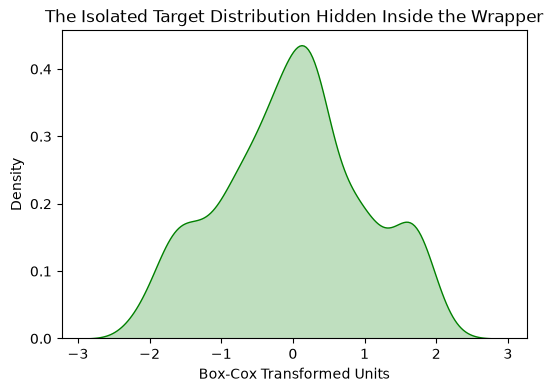

In [265]:
# Manually accessing the internal transformer to see what the model saw
internal_transformed_y = final_model.transformer_.transform(
    y_train.values.reshape(-1, 1)
)

# Plot the hidden normalized curve
plt.figure(figsize=(6, 4))
sns.kdeplot(internal_transformed_y.ravel(), fill=True, color="green")
plt.title("The Isolated Target Distribution Hidden Inside the Wrapper")
plt.xlabel("Box-Cox Transformed Units")
plt.show()


In [266]:
final_model.transformer_.transform( y_train.values.reshape(-1, 1)).ravel()

array([-0.01277119, -0.09443974,  1.21625813, ...,  0.27618   ,
        1.84897385,  0.10342611], shape=(1070,))

In [267]:
y_train.values.reshape(-1, 1)

array([[ 9193.8385 ],
       [ 8534.6718 ],
       [27117.99378],
       ...,
       [11931.12525],
       [46113.511  ],
       [10214.636  ]], shape=(1070, 1))